In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import os
import sys
import time
import json
import pandas as pd

from google.colab import userdata
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
assert os.environ["TAVILY_API_KEY"]
assert os.environ["GEMINI_API_KEY"]


In [3]:
# Cell 1: Set project paths



project_root = '/content/drive/MyDrive/UoP/COMP3000/dual_dimension_misinformation_analyzer'
backend_root = os.path.join(project_root, "backend")
frontend_root = os.path.join(project_root, "frontend")
dataset_root = os.path.join(project_root, "dataset")
FEVER_dataset_root = os.path.join(dataset_root, "FEVER")
LIAR_dataset_root = os.path.join(dataset_root, "LIAR")

assert os.path.isdir(project_root), project_root
assert os.path.isdir(backend_root), backend_root
assert os.path.isdir(frontend_root), frontend_root
assert os.path.isdir(dataset_root), dataset_root
assert os.path.isdir(FEVER_dataset_root), FEVER_dataset_root
assert os.path.isdir(LIAR_dataset_root), LIAR_dataset_root

sys.path.append(backend_root)

In [4]:
from atomizer.atomizer_service import atomize_for_pipeline
from fact_checking.fact_check_service import analyze_fact_check_claims
from api_contract import AnalysisOptions

In [5]:
# Check Tavily API request

from fact_checking.search import fetch_search_evidence

result = fetch_search_evidence("The Earth orbits the Sun.", max_results=3)

print("raw_count:", len(result.evidence))



raw_count: 3


In [6]:
# Cell 3: Load FEVER dataset

FEVER_csv_path = os.path.join(FEVER_dataset_root, "paper_test.csv")

assert os.path.isfile(FEVER_csv_path), FEVER_csv_path

FEVER_df = pd.read_csv(FEVER_csv_path)

print("FEVER rows:", len(FEVER_df))
print("Columns:", FEVER_df.columns.tolist())

display(FEVER_df.head())
display(FEVER_df["label"].value_counts())


FEVER rows: 9999
Columns: ['id', 'label', 'claim']


,id,label,claim
0,113501,NOT ENOUGH INFO,Grease had bad reviews.
1,163803,SUPPORTS,Ukrainian Soviet Socialist Republic was a foun...
2,70041,SUPPORTS,2 Hearts is a musical composition by Minogue.
3,202314,REFUTES,The New Jersey Turnpike has zero shoulders.
4,57085,NOT ENOUGH INFO,Legendary Entertainment is the owner of Wanda ...


,count
label,
NOT ENOUGH INFO,3333
SUPPORTS,3333
REFUTES,3333


In [7]:
# Cell 4: Sample 50 FEVER claims

SEED = 43

# 50 cannot be exactly balanced across 3 labels.
# This uses a near-balanced setup.
sample_plan = {
    "SUPPORTS": 17,
    "REFUTES": 17,
    "NOT ENOUGH INFO": 16,
}

sample_parts = []

for label_name, sample_count in sample_plan.items():
    label_rows = FEVER_df[FEVER_df["label"] == label_name].copy()

    assert len(label_rows) >= sample_count, label_name

    sampled_rows = label_rows.sample(
        n=sample_count,
        random_state=SEED,
    )

    sample_parts.append(sampled_rows)

test_df = pd.concat(sample_parts)

# Shuffle so the batch is not grouped by label.
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Sample size:", len(test_df))
display(test_df["label"].value_counts())
display(test_df.head(50))


Sample size: 50


,count
label,
REFUTES,17
SUPPORTS,17
NOT ENOUGH INFO,16


,id,label,claim
0,143264,REFUTES,Bonobos do not have an estimated population of...
1,64545,NOT ENOUGH INFO,The Catcher in the Rye examines themes such as...
2,85066,REFUTES,Samsung entered the electronics industry in th...
3,103116,SUPPORTS,"Jack Dylan Grazer is a child actor, who is an ..."
4,124620,REFUTES,The Quiet only stars Hillary Clinton.
5,12173,NOT ENOUGH INFO,Konidela Production Company is a film producti...
6,13981,NOT ENOUGH INFO,Sierra Morena has a strong set of trails.
7,89322,SUPPORTS,Simon Pegg is English.
8,198435,SUPPORTS,"In 1860, Arthur Schopenhauer died."
9,44874,NOT ENOUGH INFO,Riz Ahmed is an award nominated deep-sea diver.


In [8]:
# Cell 5: Helper functions

def verdict_to_fever_label(branch_status, verdict):
    if branch_status not in ["success", "partial_success"]:
        return "NOT ENOUGH INFO"

    if verdict in ["True", "Mostly True"]:
        return "SUPPORTS"

    if verdict in ["False", "Mostly False"]:
        return "REFUTES"

    return "NOT ENOUGH INFO"


def model_to_dict(value):
    if hasattr(value, "model_dump"):
        return value.model_dump()
    if hasattr(value, "dict"):
        return value.dict()
    return value


def safe_round(value, digits=4):
    if value is None:
        return None
    return round(float(value), digits)


def count_fact_claims(atomizer_output):
    count = 0
    for group in atomizer_output.claim_groups:
        count += len(group.fact_check_claims)
    return count


def collect_fact_claim_statuses(fact_checking_result):
    statuses = []
    for factual_claim in fact_checking_result.factual_claims:
        statuses.append(factual_claim.status)
    return "; ".join(statuses)


def collect_fact_claim_verdicts(fact_checking_result):
    verdicts = []
    for factual_claim in fact_checking_result.factual_claims:
        verdicts.append(str(factual_claim.verdict))
    return "; ".join(verdicts)


def collect_fact_claim_truth_scores(fact_checking_result):
    scores = []
    for factual_claim in fact_checking_result.factual_claims:
        scores.append(str(safe_round(factual_claim.truth_score)))
    return "; ".join(scores)


def count_selected_evidence(fact_checking_result):
    total = 0
    for factual_claim in fact_checking_result.factual_claims:
        total += len(factual_claim.evidence)
    return total


def count_raw_evidence(fact_checking_result):
    total = 0
    for factual_claim in fact_checking_result.factual_claims:
        total += factual_claim.metadata.search_raw_evidence_count
    return total


def was_fallback_used(fact_checking_result):
    for factual_claim in fact_checking_result.factual_claims:
        if factual_claim.metadata.fallback_used:
            return True
    return False


def get_retrieval_queries(fact_checking_result):
    queries = []
    for factual_claim in fact_checking_result.factual_claims:
        query = factual_claim.metadata.retrieval_query_used
        if query:
            queries.append(query)
    return " | ".join(queries)


In [9]:
# Cell 6A: Run atomizer

atomizer_rows = []
atomizer_outputs = {}

for index, row in test_df.iterrows():
    fever_id = row["id"]
    claim_text = str(row["claim"])
    FEVER_label = row["label"]

    start_time = time.time()

    try:
        atomizer_output = atomize_for_pipeline(claim_text)

        runtime = time.time() - start_time

        fact_claim_count = count_fact_claims(atomizer_output)

        atomizer_outputs[index] = atomizer_output

        # Collect atomizer details for display.
        original_sentences = []
        text_feature_texts = []
        atomized_claims = []
        atomized_entities = []
        atomized_relations = []
        atomized_constraints = []

        for claim_group in atomizer_output.claim_groups:
            original_sentences.append(claim_group.original_sentence)
            text_feature_texts.append(claim_group.text_feature_text)

            for fact_claim in claim_group.fact_check_claims:
                atomized_claims.append(fact_claim.claim)
                atomized_entities.append("; ".join(fact_claim.entities))
                atomized_relations.append(fact_claim.relation)
                atomized_constraints.append("; ".join(fact_claim.constraints))

        atomizer_rows.append({
            "row_number": index + 1,
            "atomizer_status": atomizer_output.status,

            "fever_id": fever_id,
            "claim": claim_text,
            "FEVER_label": FEVER_label,

            "ignored_sentence_count": len(atomizer_output.ignored_sentences),
            "ignored_sentences": " | ".join(atomizer_output.ignored_sentences),

            "claim_group_count": len(atomizer_output.claim_groups),
            "fact_claim_count": fact_claim_count,

            "original_sentences": " | ".join(original_sentences),
            "text_feature_texts": " | ".join(text_feature_texts),

            "atomized_claims": " | ".join(atomized_claims),
            "entities": " | ".join(atomized_entities),
            "relations": " | ".join(atomized_relations),
            "constraints": " | ".join(atomized_constraints),

            "atomizer_runtime_seconds": round(runtime, 2),
            "atomizer_error": atomizer_output.message,
        })

        print(f"Atomizing {index + 1}, status:", atomizer_output.status)
        print("Fact claims:", fact_claim_count)

        # Print details in a readable way.
        for claim_group in atomizer_output.claim_groups:
            for fact_claim in claim_group.fact_check_claims:
                print("  Claim:", fact_claim.claim)
                print("  Entities:", fact_claim.entities)
                print("  Relation:", fact_claim.relation)
                print("  Constraints:", fact_claim.constraints)

        print()

    except Exception as error:
        runtime = time.time() - start_time

        atomizer_outputs[index] = None

        atomizer_rows.append({
            "row_number": index + 1,
            "atomizer_status": "ERROR",

            "fever_id": fever_id,
            "claim": claim_text,
            "FEVER_label": FEVER_label,

            "ignored_sentence_count": 0,
            "ignored_sentences": "",

            "claim_group_count": 0,
            "fact_claim_count": 0,

            "original_sentences": "",
            "text_feature_texts": "",

            "atomized_claims": "",
            "entities": "",
            "relations": "",
            "constraints": "",

            "atomizer_runtime_seconds": round(runtime, 2),
            "atomizer_error": str(error),
        })

        print(f"Atomizing {index + 1}, ERROR:", error)
        print()

atomizer_df = pd.DataFrame(atomizer_rows)
display(atomizer_df)


Atomizing 1, status: success
Fact claims: 1
  Claim: The estimated population of bonobos is not more than 29,500.
  Entities: ['Bonobos']
  Relation: population estimate
  Constraints: ['not more than 29,500']

Atomizing 2, status: success
Fact claims: 1
  Claim: The Catcher in the Rye examines themes such as innocence and connection.
  Entities: ['The Catcher in the Rye']
  Relation: examines themes
  Constraints: ['innocence', 'connection']

Atomizing 3, status: success
Fact claims: 1
  Claim: Samsung entered the electronics industry in the late 1970s.
  Entities: ['Samsung', 'electronics industry']
  Relation: entered
  Constraints: ['late 1970s']

Atomizing 4, status: success
Fact claims: 2
  Claim: Jack Dylan Grazer is a child actor.
  Entities: ['Jack Dylan Grazer']
  Relation: is a
  Constraints: ['child actor']
  Claim: Jack Dylan Grazer is an American.
  Entities: ['Jack Dylan Grazer']
  Relation: is a
  Constraints: ['American']

Atomizing 5, status: success
Fact claims: 1
  

,row_number,atomizer_status,fever_id,claim,FEVER_label,ignored_sentence_count,ignored_sentences,claim_group_count,fact_claim_count,original_sentences,text_feature_texts,atomized_claims,entities,relations,constraints,atomizer_runtime_seconds,atomizer_error
0,1,success,143264,Bonobos do not have an estimated population of...,REFUTES,0,,1,1,Bonobos do not have an estimated population of...,Bonobos do not have an estimated population of...,The estimated population of bonobos is not mor...,Bonobos,population estimate,"not more than 29,500",1.47,
1,2,success,64545,The Catcher in the Rye examines themes such as...,NOT ENOUGH INFO,0,,1,1,The Catcher in the Rye examines themes such as...,The Catcher in the Rye examines themes such as...,The Catcher in the Rye examines themes such as...,The Catcher in the Rye,examines themes,innocence; connection,1.46,
2,3,success,85066,Samsung entered the electronics industry in th...,REFUTES,0,,1,1,Samsung entered the electronics industry in th...,Samsung entered the electronics industry in th...,Samsung entered the electronics industry in th...,Samsung; electronics industry,entered,late 1970s,1.33,
3,4,success,103116,"Jack Dylan Grazer is a child actor, who is an ...",SUPPORTS,0,,1,2,"Jack Dylan Grazer is a child actor, who is an ...","Jack Dylan Grazer is a child actor, who is an ...",Jack Dylan Grazer is a child actor. | Jack Dyl...,Jack Dylan Grazer | Jack Dylan Grazer,is a | is a,child actor | American,1.48,
4,5,success,124620,The Quiet only stars Hillary Clinton.,REFUTES,0,,1,1,The Quiet only stars Hillary Clinton.,The Quiet only stars Hillary Clinton.,Hillary Clinton is the only star of The Quiet.,Hillary Clinton; The Quiet,is star of,only,0.90,
5,6,success,12173,Konidela Production Company is a film producti...,NOT ENOUGH INFO,0,,1,2,Konidela Production Company is a film producti...,Konidela Production Company is a film producti...,Konidela Production Company is a film producti...,Konidela Production Company | Konidela Product...,is a | is,| successful,1.36,
6,7,success,13981,Sierra Morena has a strong set of trails.,NOT ENOUGH INFO,0,,1,1,Sierra Morena has a strong set of trails.,Sierra Morena has a strong set of trails.,Sierra Morena has a strong set of trails.,Sierra Morena,has,strong set of trails,1.25,
7,8,success,89322,Simon Pegg is English.,SUPPORTS,0,,1,1,Simon Pegg is English.,Simon Pegg is English.,Simon Pegg is English.,Simon Pegg,is nationality,English,1.14,
8,9,success,198435,"In 1860, Arthur Schopenhauer died.",SUPPORTS,0,,1,1,"In 1860, Arthur Schopenhauer died.","In 1860, Arthur Schopenhauer died.",Arthur Schopenhauer died in 1860.,Arthur Schopenhauer,died,in 1860,1.36,
9,10,success,44874,Riz Ahmed is an award nominated deep-sea diver.,NOT ENOUGH INFO,0,,1,1,Riz Ahmed is an award nominated deep-sea diver.,Riz Ahmed is an award nominated deep-sea diver.,Riz Ahmed is an award-nominated deep-sea diver.,Riz Ahmed,is a,award-nominated deep-sea diver,1.17,


In [10]:
# Cell 6B: Run fact-checking branch

options = AnalysisOptions(
    use_query_rewrite=True
)

fact_rows = []
full_outputs = []

for index, row in test_df.iterrows():
    fever_id = row["id"]
    claim_text = str(row["claim"])
    FEVER_label = row["label"]

    start_time = time.time()

    try:
        atomizer_output = atomizer_outputs[index]

        atomized_claims = []
        atomized_entities = []
        atomized_relations = []
        atomized_constraints = []

        for claim_group in atomizer_output.claim_groups:
            for fact_claim in claim_group.fact_check_claims:
                atomized_claims.append(fact_claim.claim)
                atomized_entities.append("; ".join(fact_claim.entities))
                atomized_relations.append(fact_claim.relation)
                atomized_constraints.append("; ".join(fact_claim.constraints))

        atomized_claims_text = " | ".join(atomized_claims)
        entities_text = " | ".join(atomized_entities)
        relations_text = " | ".join(atomized_relations)
        constraints_text = " | ".join(atomized_constraints)

        fact_checking_result = analyze_fact_check_claims(
            claim_groups=atomizer_output.claim_groups,
            raw_options=options,
        )

        runtime = time.time() - start_time

        decision_confidences = []
        evidence_sufficiencies = []

        for factual_claim in fact_checking_result.factual_claims:
            decision_confidences.append(factual_claim.decision_confidence)
            evidence_sufficiencies.append(factual_claim.evidence_sufficiency)

        fact_rows.append({
            "row_number": index + 1,
            "branch_status": fact_checking_result.status,
            "fever_id": fever_id,

            "claim": claim_text,
            "FEVER_label": FEVER_label,
            "branch_verdict": fact_checking_result.verdict,
            "branch_truth_score": safe_round(fact_checking_result.truth_score),

            "atomized_claims": atomized_claims_text,
            "entities": entities_text,
            "relations": relations_text,
            "constraints": constraints_text,

            "decision_confidences": " | ".join(decision_confidences),
            "evidence_sufficiencies": " | ".join(evidence_sufficiencies),
            "selected_evidence_count": count_selected_evidence(fact_checking_result),
            "raw_evidence_count": count_raw_evidence(fact_checking_result),
            "fallback_used": was_fallback_used(fact_checking_result),
            "retrieval_queries": get_retrieval_queries(fact_checking_result),

            "fact_checking_runtime_seconds": round(runtime, 2),
            "total_runtime_seconds": round(runtime + atomizer_df.loc[index, "atomizer_runtime_seconds"], 2),
            "error": "",
        })

        full_outputs.append({
            "fever_id": int(fever_id),
            "claim": claim_text,
            "FEVER_label": FEVER_label,
            "atomizer_output": model_to_dict(atomizer_output),
            "fact_checking_output": model_to_dict(fact_checking_result),
        })

        print(f"Fact-checking {index + 1}, status:", fact_checking_result.status)
        print()

    except Exception as error:
        runtime = time.time() - start_time

        fact_rows.append({
            "row_number": index + 1,
            "branch_status": "ERROR",
            "fever_id": fever_id,

            "claim": claim_text,
            "FEVER_label": FEVER_label,
            "branch_verdict": None,
            "branch_truth_score": None,

            "atomized_claims": "",
            "entities": "",
            "relations": "",
            "constraints": "",

            "decision_confidences": "",
            "evidence_sufficiencies": "",
            "selected_evidence_count": 0,
            "raw_evidence_count": 0,
            "fallback_used": False,
            "retrieval_queries": "",

            "fact_checking_runtime_seconds": round(runtime, 2),
            "total_runtime_seconds": round(runtime, 2),
            "error": str(error),
        })

        print(f"Fact-checking {index + 1}, ERROR:", error)
        print()

results_df = pd.DataFrame(fact_rows)
display(results_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fact-checking 1, status: success

Fact-checking 2, status: success

Fact-checking 3, status: success

Fact-checking 4, status: success

Fact-checking 5, status: success

Fact-checking 6, status: success

Fact-checking 7, status: success

Fact-checking 8, status: success

Fact-checking 9, status: success

Fact-checking 10, status: success

Fact-checking 11, status: success

Fact-checking 12, status: success

Fact-checking 13, status: success

Fact-checking 14, status: success

Fact-checking 15, status: success

Fact-checking 16, status: success

Fact-checking 17, status: success

Fact-checking 18, status: success

Fact-checking 19, status: success

Fact-checking 20, status: success

Fact-checking 21, status: success

Fact-checking 22, status: success

Fact-checking 23, status: success

Fact-checking 24, status: success

Fact-checking 25, status: success

Fact-checking 26, status: success

Fact-checking 27, status: success

Fact-checking 28, status: success

Fact-checking 29, status: suc

,row_number,branch_status,fever_id,claim,FEVER_label,branch_verdict,branch_truth_score,atomized_claims,entities,relations,constraints,decision_confidences,evidence_sufficiencies,selected_evidence_count,raw_evidence_count,fallback_used,retrieval_queries,fact_checking_runtime_seconds,total_runtime_seconds,error
0,1,success,143264,Bonobos do not have an estimated population of...,REFUTES,True,0.8700,The estimated population of bonobos is not mor...,Bonobos,population estimate,"not more than 29,500",high,sufficient,3,9,False,The estimated population of bonobos is not mor...,22.30,23.77,
1,2,success,64545,The Catcher in the Rye examines themes such as...,NOT ENOUGH INFO,True,0.8850,The Catcher in the Rye examines themes such as...,The Catcher in the Rye,examines themes,innocence; connection,high,sufficient,3,9,False,The Catcher in the Rye examines themes such as...,6.05,7.51,
2,3,success,85066,Samsung entered the electronics industry in th...,REFUTES,False,0.1150,Samsung entered the electronics industry in th...,Samsung; electronics industry,entered,late 1970s,low,sufficient,3,9,False,Samsung entered the electronics industry in th...,6.67,8.00,
3,4,success,103116,"Jack Dylan Grazer is a child actor, who is an ...",SUPPORTS,True,0.9000,Jack Dylan Grazer is a child actor. | Jack Dyl...,Jack Dylan Grazer | Jack Dylan Grazer,is a | is a,child actor | American,low | high,insufficient | sufficient,6,19,False,Jack Dylan Grazer is a child actor. | Jack Dyl...,9.47,10.95,
4,5,success,124620,The Quiet only stars Hillary Clinton.,REFUTES,Mostly False,0.4250,Hillary Clinton is the only star of The Quiet.,Hillary Clinton; The Quiet,is star of,only,low,low,3,10,False,Hillary Clinton is the only star of The Quiet.,9.26,10.16,
5,6,success,12173,Konidela Production Company is a film producti...,NOT ENOUGH INFO,Mostly True,0.7300,Konidela Production Company is a film producti...,Konidela Production Company | Konidela Product...,is a | is,| successful,high | low,sufficient | insufficient,6,19,False,Konidela Production Company is a film producti...,8.57,9.93,
6,7,success,13981,Sierra Morena has a strong set of trails.,NOT ENOUGH INFO,True,0.8925,Sierra Morena has a strong set of trails.,Sierra Morena,has,strong set of trails,medium,sufficient,3,10,False,Sierra Morena has a strong set of trails.,5.79,7.04,
7,8,success,89322,Simon Pegg is English.,SUPPORTS,True,0.9150,Simon Pegg is English.,Simon Pegg,is nationality,English,high,sufficient,3,10,False,Simon Pegg is English.,7.58,8.72,
8,9,success,198435,"In 1860, Arthur Schopenhauer died.",SUPPORTS,True,0.9150,Arthur Schopenhauer died in 1860.,Arthur Schopenhauer,died,in 1860,high,sufficient,3,9,False,Arthur Schopenhauer died in 1860.,5.99,7.35,
9,10,success,44874,Riz Ahmed is an award nominated deep-sea diver.,NOT ENOUGH INFO,Mostly False,0.4400,Riz Ahmed is an award-nominated deep-sea diver.,Riz Ahmed,is a,award-nominated deep-sea diver,low,low,3,10,False,Riz Ahmed is an award-nominated deep-sea diver.,6.82,7.99,


In [12]:
# Cell 7: Calculate metrics and confusion matrix

def verdict_to_fever_label(verdict):
    if verdict in ["True", "Mostly True"]:
        return "SUPPORTS"
    if verdict in ["False", "Mostly False"]:
        return "REFUTES"
    return "NOT ENOUGH INFO"


results_df["predicted_label"] = results_df["branch_verdict"].apply(verdict_to_fever_label)
results_df["correct"] = results_df["predicted_label"] == results_df["FEVER_label"]

labels = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]

accuracy = results_df["correct"].mean()

print("Total claims:", len(results_df))
print("Accuracy:", round(accuracy, 4))
print("Correct:", int(results_df["correct"].sum()), "/", len(results_df))

confusion_df = pd.crosstab(
    results_df["FEVER_label"],
    results_df["predicted_label"],
    rownames=["FEVER label"],
    colnames=["Predicted label"],
    dropna=False,
)

confusion_df = confusion_df.reindex(
    index=labels,
    columns=labels,
    fill_value=0,
)

print("Confusion matrix:")
display(confusion_df)


metric_rows = []

for label_name in labels:
    tp = len(results_df[
        (results_df["FEVER_label"] == label_name) &
        (results_df["predicted_label"] == label_name)
    ])

    fp = len(results_df[
        (results_df["FEVER_label"] != label_name) &
        (results_df["predicted_label"] == label_name)
    ])

    fn = len(results_df[
        (results_df["FEVER_label"] == label_name) &
        (results_df["predicted_label"] != label_name)
    ])

    if tp + fp == 0:
        precision = 0
    else:
        precision = tp / (tp + fp)

    if tp + fn == 0:
        recall = 0
    else:
        recall = tp / (tp + fn)

    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    metric_rows.append({
        "label": label_name,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "support": int((results_df["FEVER_label"] == label_name).sum()),
    })

metrics_df = pd.DataFrame(metric_rows)
macro_f1 = metrics_df["f1"].mean()

print("Macro-F1:", round(macro_f1, 4))
display(metrics_df)


Total claims: 50
Accuracy: 0.56
Correct: 28 / 50
Confusion matrix:


Predicted label,SUPPORTS,REFUTES,NOT ENOUGH INFO
FEVER label,,,
SUPPORTS,14,1,2
REFUTES,6,11,0
NOT ENOUGH INFO,10,3,3


Macro-F1: 0.523


,label,precision,recall,f1,support
0,SUPPORTS,0.4667,0.8235,0.5957,17
1,REFUTES,0.7333,0.6471,0.6875,17
2,NOT ENOUGH INFO,0.6000,0.1875,0.2857,16


In [15]:
# Cell 8: Simple status and runtime summary

print("Branch status:")
display(results_df["branch_status"].value_counts(dropna=False).reset_index())

print("Fallback used:")
display(results_df["fallback_used"].value_counts(dropna=False).reset_index())

summary_df = pd.DataFrame([
    {
        "mean_raw_evidence_count": round(results_df["raw_evidence_count"].mean(), 4),
        "mean_selected_evidence_count": round(results_df["selected_evidence_count"].mean(), 4),
        "mean_fact_checking_runtime_seconds": round(results_df["fact_checking_runtime_seconds"].mean(), 4),
        "mean_total_runtime_seconds": round(results_df["total_runtime_seconds"].mean(), 4),
    }
])

display(summary_df)


Branch status:


,branch_status,count
0,success,50


Fallback used:


,fallback_used,count
0,False,50


,mean_raw_evidence_count,mean_selected_evidence_count,mean_fact_checking_runtime_seconds,mean_total_runtime_seconds
0,10.26,3.24,7.393,8.7376


In [16]:
# Cell 9: Inspect wrong cases

wrong_df = results_df[results_df["correct"] == False].copy()

print("Wrong cases:", len(wrong_df))

display(wrong_df[[
    "row_number",
    "fever_id",
    "claim",
    "FEVER_label",
    "predicted_label",
    "branch_status",
    "branch_verdict",
    "branch_truth_score",
    "atomized_claims",
    "relations",
    "constraints",
    "selected_evidence_count",
    "retrieval_queries",
    "error",
]])


Wrong cases: 22


,row_number,fever_id,claim,FEVER_label,predicted_label,branch_status,branch_verdict,branch_truth_score,atomized_claims,relations,constraints,selected_evidence_count,retrieval_queries,error
0,1,143264,Bonobos do not have an estimated population of...,REFUTES,SUPPORTS,success,True,0.8700,The estimated population of bonobos is not mor...,population estimate,"not more than 29,500",3,The estimated population of bonobos is not mor...,
1,2,64545,The Catcher in the Rye examines themes such as...,NOT ENOUGH INFO,SUPPORTS,success,True,0.8850,The Catcher in the Rye examines themes such as...,examines themes,innocence; connection,3,The Catcher in the Rye examines themes such as...,
5,6,12173,Konidela Production Company is a film producti...,NOT ENOUGH INFO,SUPPORTS,success,Mostly True,0.7300,Konidela Production Company is a film producti...,is a | is,| successful,6,Konidela Production Company is a film producti...,
6,7,13981,Sierra Morena has a strong set of trails.,NOT ENOUGH INFO,SUPPORTS,success,True,0.8925,Sierra Morena has a strong set of trails.,has,strong set of trails,3,Sierra Morena has a strong set of trails.,
9,10,44874,Riz Ahmed is an award nominated deep-sea diver.,NOT ENOUGH INFO,REFUTES,success,Mostly False,0.4400,Riz Ahmed is an award-nominated deep-sea diver.,is a,award-nominated deep-sea diver,3,Riz Ahmed is an award-nominated deep-sea diver.,
13,14,204978,Tyler Perry is a son.,NOT ENOUGH INFO,SUPPORTS,success,True,0.9150,Tyler Perry is a son.,is a,,3,Tyler Perry is a son.,
15,16,182042,The Fly is a film from the United States.,SUPPORTS,NOT ENOUGH INFO,success,Neutral,0.5330,The Fly is a film from the United States.,is from,United States,3,The Fly is a film from the United States.,
20,21,219695,Corsica is at war with France.,NOT ENOUGH INFO,SUPPORTS,success,True,0.8730,Corsica is at war with France.,is at war with,,3,Corsica is at war with France.,
21,22,124993,Doxycycline may cause headaches.,REFUTES,SUPPORTS,success,True,0.9000,Doxycycline may cause headaches.,may cause,headaches,3,Doxycycline may cause headaches.,
23,24,126314,In states still using the electric chair to ex...,NOT ENOUGH INFO,SUPPORTS,success,True,0.8775,In states still using the electric chair to ex...,allowed choice of,in states still using the electric chair to ex...,3,In states still using the electric chair to ex...,


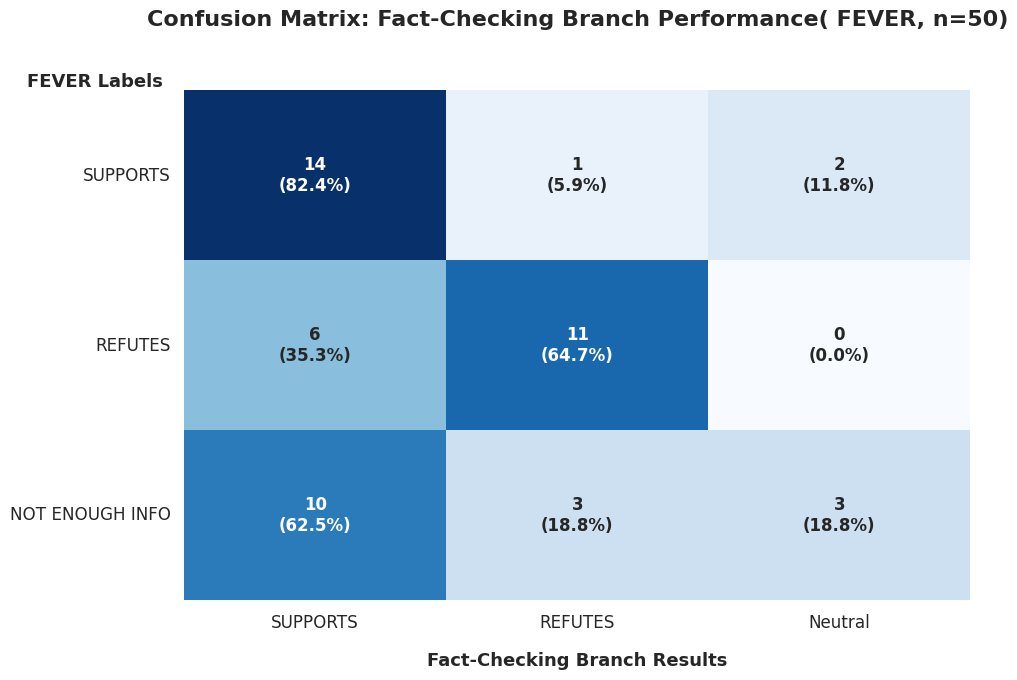

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 准备更新后的数据 (n=50)
labels = ['SUPPORTS', 'REFUTES', 'NOT ENOUGH INFO']
predictions = ['SUPPORTS', 'REFUTES', 'Neutral']

data = np.array([
    [14, 1, 2],
    [6, 11, 0],
    [10, 3, 3]
])

# 计算百分比
data_norm = data.astype('float') / data.sum(axis=1)[:, np.newaxis]
annot_text = np.array([["{}\n({:.1%})".format(val, pct) for val, pct in zip(row_val, row_pct)]
                       for row_val, row_pct in zip(data, data_norm)])

# 2. 绘图设置
fig, ax = plt.subplots(figsize=(10, 7))
sns.set_theme(style="white", font_scale=1.1)

# 绘制 Heatmap，去掉右侧图例
sns.heatmap(data,
            annot=annot_text,
            fmt="",
            cmap='Blues',
            xticklabels=predictions,
            yticklabels=labels,
            cbar=False,
            annot_kws={"size": 12, "weight": "bold"},
            ax=ax)

# 3. 标签转正
plt.yticks(rotation=0)
plt.xticks(rotation=0)

# 4. 核心改进：纵轴标题挪到左上角水平显示
ax.text(-0.2, 1.0, 'FEVER Labels',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=13,
        fontweight='bold')

# 5. 标题与轴标签
# 标题反映了这是一个经过 Open-Web 调整后的结果
plt.title('Confusion Matrix: Fact-Checking Branch Performance( FEVER, n=50)\n',
          fontsize=16, pad=30, fontweight='bold')
plt.xlabel('Fact-Checking Branch Results', fontsize=13, labelpad=15, fontweight='bold')

plt.ylabel('')

plt.tight_layout()
plt.show()